# gym — Confidence-Weighted Merge Test (v3) — Real Split-MNIST

This is the UPDATED version of gym_colab_confidence_weighted_test that fixes
the fundamental problem in the v2 notebook:

  **PROBLEM (v2):** All strategies gave digits5-9 = 0.00% in the imbalanced case.
  **WHY:**  Every strategy blended raw weights or ran TIES sign-election dominated by
        branch A (30k images, large Δ). Branch B starved (300 images, tiny Δ)
        was completely drowned out regardless of confidence weighting.
  **FIX:**  Mode 2 — confidence-weighted TASK-VECTOR average (`--ties false`)
        operates on Δ = model - root, so initialization noise is separated from
        learned signal. Both confidence AND delta magnitude discount the
        starved branch proportionally. The learned 5-9 signal survives.

Run this in Colab after:
  1. Pushing the updated gym repo (includes `--ties` CLI flag)
  2. `pip install safetensors`

**Strategies tested:**
*   `average`   — plain 50/50 mean of raw weights (null hypothesis)
*   `cw-raw`    — confidence-weighted mean of raw weights (FedAvg variant)
*   `ties`      — trim → elect sign by magnitude → disjoint merge
*   `cw-ties`   — TIES with confidence-weighted sign election
*   `cw-tv`     — confidence-weighted TASK-VECTOR average (THE fix)
              merged = root + lambda * sum(confidence_i * delta_i)


In [1]:
%%bash
# ─── Step 0: Install Node.js 22 ────────────────────
curl -fsSL https://deb.nodesource.com/setup_22.x | bash - > /dev/null 2>&1
apt-get install -y nodejs > /dev/null 2>&1


In [2]:
# ─── Step 1: Clone or pull gym repo ──────────────────────────────────────────
import os
import subprocess
import json

GITHUB_REPO_URL = "https://github.com/Sakshamvijay-078/gym-gitForLLm"
REPO_DIR = "/content/gym"
GYM = f"node --experimental-transform-types {REPO_DIR}/packages/cli/src/index.ts"
WD = "/content"
REFS = "/content/.gym/refs.json"

if os.path.exists(REPO_DIR):
    os.system(f"cd {REPO_DIR} && git pull")
else:
    ret = os.system(f"git clone {GITHUB_REPO_URL} {REPO_DIR}")
    if ret != 0:
        raise RuntimeError("❌ git clone failed. Check GITHUB_REPO_URL.")

print(f"\n✅ Repo ready at {REPO_DIR}")



✅ Repo ready at /content/gym


In [3]:
%%bash
# ─── Step 2: Run all smoke tests ─────────────────────────────────────────────
for f in diskBlobStore manifestStore merge codecs confidenceWeighted; do
  node --experimental-transform-types /content/gym/packages/core-versioning/test/$f.smoke.ts
done


ok - put() returns a 64-char sha256 hash
ok - get(hash) returns exactly the bytes that were put
ok - exists(hash) is true after put
ok - get() on a missing hash throws BlobNotFoundError
ok - exists() is false for a hash that was never stored
ok - putting identical bytes twice returns the identical hash
ok - dedup: no new object written for identical bytes
ok - different bytes produce a different hash
ok - blob is stored under git-style sharded directory

All checks passed.
ok - root manifest commits with parents: []
ok - round 1 manifest correctly points at root as parent
ok - two concurrent commits from the same parent get distinct hashes
ok - round 1 has exactly two children — a real branch, nothing overwritten
ok - log() from branch A walks back 3 manifests: branchA -> round1 -> root
ok - log() returns the chain newest-first in the correct order
ok - the root manifest terminates the chain with parents: []
ok - commonAncestor() correctly finds round 1 as the merge-base of both branch

(node:8344) ExperimentalWarning: Transform Types is an experimental feature and might change at any time
(Use `node --trace-warnings ...` to show where the warning was created)
(node:8355) ExperimentalWarning: Transform Types is an experimental feature and might change at any time
(Use `node --trace-warnings ...` to show where the warning was created)
(node:8366) ExperimentalWarning: Transform Types is an experimental feature and might change at any time
(Use `node --trace-warnings ...` to show where the warning was created)
(node:8373) ExperimentalWarning: Transform Types is an experimental feature and might change at any time
(Use `node --trace-warnings ...` to show where the warning was created)
(node:8384) ExperimentalWarning: Transform Types is an experimental feature and might change at any time
(Use `node --trace-warnings ...` to show where the warning was created)


In [4]:
# ─── Step 3: Python deps ──────────────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from safetensors.torch import save_file, load_file

print(f"✅ torch=={torch.__version__}  safetensors installed")


✅ torch==2.11.0+cpu  safetensors installed


In [5]:
# ─── Step 4: Load MNIST, build splits ────────────────────────────────────────
transform = transforms.Compose([transforms.ToTensor()])
train_full = datasets.MNIST(root="/content/data", train=True, download=True, transform=transform)
test_full  = datasets.MNIST(root="/content/data", train=False, download=True, transform=transform)

def indices_for_classes(dataset, classes):
    targets = dataset.targets
    mask = torch.isin(targets, torch.tensor(classes))
    return torch.where(mask)[0].tolist()

SHARD_A_CLASSES = [0, 1, 2, 3, 4]
SHARD_B_CLASSES = [5, 6, 7, 8, 9]

shard_a       = Subset(train_full, indices_for_classes(train_full, SHARD_A_CLASSES))
shard_b_full  = Subset(train_full, indices_for_classes(train_full, SHARD_B_CLASSES))
test_a        = Subset(test_full,  indices_for_classes(test_full,  SHARD_A_CLASSES))
test_b        = Subset(test_full,  indices_for_classes(test_full,  SHARD_B_CLASSES))

torch.manual_seed(42)
STARVED_SIZE = 300
starved_indices = torch.randperm(len(shard_b_full))[:STARVED_SIZE].tolist()
shard_b_starved = Subset(shard_b_full, starved_indices)

print(f"Shard A (digits 0-4):          {len(shard_a):,} real training images")
print(f"Shard B, full (digits 5-9):    {len(shard_b_full):,} real training images")
print(f"Shard B, STARVED (digits 5-9): {len(shard_b_starved):,} real training images  <-- deliberately tiny")
print(f"Test set A (digits 0-4):       {len(test_a):,} real held-out images")
print(f"Test set B (digits 5-9):       {len(test_b):,} real held-out images")


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 478kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.40MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.4MB/s]

Shard A (digits 0-4):          30,596 real training images
Shard B, full (digits 5-9):    29,404 real training images
Shard B, STARVED (digits 5-9): 300 real training images  <-- deliberately tiny
Test set A (digits 0-4):       5,139 real held-out images
Test set B (digits 5-9):       4,861 real held-out images


In [6]:
# ─── Step 5: Train three branches ────────────────────────────────────────────

class TinyMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.fc2(torch.relu(self.fc1(x)))

def train_on_shard(model, dataset, epochs=3, lr=1e-3, batch_size=128):
    loader = DataLoader(dataset, batch_size=min(batch_size, len(dataset)), shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        for x, y in loader:
            opt.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward()
            opt.step()
            total_loss += loss.item() * x.size(0)
        print(f"  epoch {epoch+1}/{epochs}  avg loss {total_loss/len(dataset):.4f}")
    return model

def save_model(model, path):
    state = {k: v.contiguous() for k, v in model.state_dict().items()}
    save_file(state, path)
    print(f"saved {path}")

os.chdir("/content")

torch.manual_seed(0)
root = TinyMLP()
save_model(root, "root.safetensors")

print("\nTraining branch_a on FULL shard A...")
branch_a = TinyMLP()
branch_a.load_state_dict(root.state_dict())
train_on_shard(branch_a, shard_a)
save_model(branch_a, "branch_a.safetensors")

print("\nTraining branch_b_full on FULL shard B...")
branch_b_full = TinyMLP()
branch_b_full.load_state_dict(root.state_dict())
train_on_shard(branch_b_full, shard_b_full)
save_model(branch_b_full, "branch_b_full.safetensors")

print(f"\nTraining branch_b_starved on only {STARVED_SIZE} images from shard B...")
branch_b_starved = TinyMLP()
branch_b_starved.load_state_dict(root.state_dict())
train_on_shard(branch_b_starved, shard_b_starved, epochs=5)
save_model(branch_b_starved, "branch_b_starved.safetensors")

print("\n✅ All real checkpoints exported")


saved root.safetensors

Training branch_a on FULL shard A...
  epoch 1/3  avg loss 0.3159
  epoch 2/3  avg loss 0.1023
  epoch 3/3  avg loss 0.0808
saved branch_a.safetensors

Training branch_b_full on FULL shard B...
  epoch 1/3  avg loss 0.4147
  epoch 2/3  avg loss 0.1615
  epoch 3/3  avg loss 0.1234
saved branch_b_full.safetensors

Training branch_b_starved on only 300 images from shard B...
  epoch 1/5  avg loss 2.1944
  epoch 2/5  avg loss 1.9397
  epoch 3/5  avg loss 1.6931
  epoch 4/5  avg loss 1.4788
  epoch 5/5  avg loss 1.2944
saved branch_b_starved.safetensors

✅ All real checkpoints exported


In [7]:
# ─── Sanity check ─────────────────────────────────────────────────────────────
@torch.no_grad()
def accuracy(model, dataset, batch_size=256):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size)
    correct, total = 0, 0
    for x, y in loader:
        pred = model(x).argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return correct / total

acc_a_self          = accuracy(branch_a, test_a)
acc_b_full_self     = accuracy(branch_b_full, test_b)
acc_b_starved_self  = accuracy(branch_b_starved, test_b)

print(f"branch_a on digits 0-4 (its own shard):          {acc_a_self:.2%}")
print(f"branch_b_full on digits 5-9 (its own shard):     {acc_b_full_self:.2%}")
print(f"branch_b_starved on digits 5-9 (its own shard):  {acc_b_starved_self:.2%}   <-- should be noticeably weaker")


branch_a on digits 0-4 (its own shard):          98.27%
branch_b_full on digits 5-9 (its own shard):     96.17%
branch_b_starved on digits 5-9 (its own shard):  69.02%   <-- should be noticeably weaker


In [8]:
# ─── Delta norm analysis (NEW — shows WHY mode 2 is different) ───────────────
print("\n─── Task Vector Norms ────────────────────────────────────────────────")
root_state = root.state_dict()
def delta_norm(model):
    total = 0.0
    for k, v in model.state_dict().items():
        diff = v.float() - root_state[k].float()
        total += (diff * diff).sum().item()
    return total ** 0.5

print(f"‖Δ_A‖          = {delta_norm(branch_a):.4f}  (30k images — large learned delta)")
print(f"‖Δ_B_full‖     = {delta_norm(branch_b_full):.4f}  (30k images — large learned delta)")
print(f"‖Δ_B_starved‖  = {delta_norm(branch_b_starved):.4f}  (300 images — tiny delta, mostly noise)")
print("\nThis is WHY raw-weight averaging fails in the imbalanced case:")
print("  average(A, B_starved) ≈ average(A, root)  because B_starved ≈ root")
print("  cw-tv correctly represents: root + 0.99·Δ_A + 0.01·Δ_B_starved")



─── Task Vector Norms ────────────────────────────────────────────────
‖Δ_A‖          = 10.2069  (30k images — large learned delta)
‖Δ_B_full‖     = 11.2055  (30k images — large learned delta)
‖Δ_B_starved‖  = 1.8221  (300 images — tiny delta, mostly noise)

This is WHY raw-weight averaging fails in the imbalanced case:
  average(A, B_starved) ≈ average(A, root)  because B_starved ≈ root
  cw-tv correctly represents: root + 0.99·Δ_A + 0.01·Δ_B_starved


In [9]:
# ─── Step 6: gym init + commit ────────────────────────────────────────────────

def gym(*args):
    result = subprocess.run(f"{GYM} {' '.join(str(a) for a in args)}", shell=True, cwd=WD, capture_output=True, text=True)
    print(result.stdout + result.stderr)
    if result.returncode != 0:
        raise RuntimeError(f"gym command failed: gym {' '.join(str(a) for a in args)}")
    return result.stdout + result.stderr

def read_hash(node_id: str) -> str:
    with open(REFS) as f:
        refs = json.load(f)
    h = refs["nodes"].get(node_id)
    if not h:
        raise RuntimeError(f"no commit recorded for node '{node_id}'")
    return h

# ADDED: Initialize the gym repository to prevent the "not a gym repository" error
gym("init")

print("--- commit root ---")
gym("commit", "--file", "root.safetensors", "--node", "seed", "--round", "0")
ROOT_HASH = read_hash("seed")

print("--- commit branch_a (tagged with REAL dataset size + metric) ---")
gym("commit", "--file", "branch_a.safetensors", "--node", "nodeA", "--round", "1",
    "--parent", ROOT_HASH, "--dataset-size", len(shard_a), "--metric", f"{acc_a_self:.4f}")
HASH_A = read_hash("nodeA")

print("--- commit branch_b_full (balanced partner) ---")
gym("commit", "--file", "branch_b_full.safetensors", "--node", "nodeB_full", "--round", "1",
    "--parent", ROOT_HASH, "--dataset-size", len(shard_b_full), "--metric", f"{acc_b_full_self:.4f}")
HASH_B_FULL = read_hash("nodeB_full")

print("--- commit branch_b_starved (imbalanced partner, tiny real dataset size) ---")
gym("commit", "--file", "branch_b_starved.safetensors", "--node", "nodeB_starved", "--round", "1",
    "--parent", ROOT_HASH, "--dataset-size", STARVED_SIZE, "--metric", f"{acc_b_starved_self:.4f}")
HASH_B_STARVED = read_hash("nodeB_starved")

print(f"\n🔑 root         : {ROOT_HASH}")
print(f"🔑 branch A      : {HASH_A}   (size={len(shard_a)}, metric={acc_a_self:.4f})")
print(f"🔑 branch B full : {HASH_B_FULL}   (size={len(shard_b_full)}, metric={acc_b_full_self:.4f})")
print(f"🔑 branch B starv: {HASH_B_STARVED}   (size={STARVED_SIZE}, metric={acc_b_starved_self:.4f})")


Initialized empty gym repository in /content/.gym
(node:8737) ExperimentalWarning: Transform Types is an experimental feature and might change at any time
(Use `node --trace-warnings ...` to show where the warning was created)

--- commit root ---
[seed round 0] c632dc59b4  (parent none — root, format safetensors)
(node:8749) ExperimentalWarning: Transform Types is an experimental feature and might change at any time
(Use `node --trace-warnings ...` to show where the warning was created)

--- commit branch_a (tagged with REAL dataset size + metric) ---
[nodeA round 1] c2971ee1cf  (parent c632dc59b4, format safetensors)
(node:8765) ExperimentalWarning: Transform Types is an experimental feature and might change at any time
(Use `node --trace-warnings ...` to show where the warning was created)

--- commit branch_b_full (balanced partner) ---
[nodeB_full round 1] c2639ef8ca  (parent c632dc59b4, format safetensors)
(node:8777) ExperimentalWarning: Transform Types is an experimental featur

In [10]:
# ─── Step 7 (v3): Run ALL 5 merge strategies ─────────────────────────────────
#
# NEW in v3: adds cw-tv (--ties false = task-vector average)
# This is the KEY experiment. See module docstring for theory.

def run_merge_set(hash_x, hash_y, label_suffix):
    runs = [
        # (strategy_name, extra_cli_args, display_mode_name)

        # Mode 1a: plain 50/50 average of raw weights (null hypothesis)
        ("average", [], "average"),

        # Mode 1b: confidence-weighted average of raw weights (FedAvg)
        # Same math as average but uses dataset-size + metric to weight.
        # Still operates on raw tensors, so barely-trained branch ≈ root.
        ("confidence-weighted", [], "cw-raw"),

        # Mode 3a: plain TIES (trim → elect sign by magnitude → disjoint merge)
        # Uses task vectors but sign election is unweighted (raw magnitude wins).
        ("ties", ["--base", "auto", "--trim", "0.5"], "ties"),

        # Mode 3b: confidence-weighted TIES
        # Sign election uses confidence-weighted mass.
        # In the imbalanced case: branch A (99% confidence) dominates sign election
        # at EVERY parameter → branch B's learned 5-9 signal is erased.
        ("confidence-weighted", ["--base", "auto", "--trim", "0.5", "--lambda", "1"], "cw-ties"),

        # Mode 2a: confidence-weighted TASK-VECTOR average with default 'sqrt' score-mode (FedProx scaling)
        ("confidence-weighted", ["--base", "auto", "--ties", "false", "--lambda", "1", "--score-mode", "sqrt"], "cw-tv-sqrt"),

        # Mode 2b: confidence-weighted TASK-VECTOR average with 'equal' weighting (1/N task-arithmetic baseline)
        ("confidence-weighted", ["--base", "auto", "--ties", "false", "--lambda", "1", "--score-mode", "equal"], "cw-tv-equal"),

        # Mode 2c: Fisher-approximate TASK-VECTOR average using delta-norm^2 parameter importance
        ("confidence-weighted", ["--base", "auto", "--ties", "false", "--lambda", "1", "--score-mode", "delta-norm"], "cw-tv-fisher"),
    ]
    files = {}
    for strategy, extra, mode in runs:
        node_id = f"merger_{mode.replace('-','')}_{label_suffix}"
        out_file = f"merged_{mode}_{label_suffix}.safetensors"
        args = ["merge", hash_x, hash_y, "--strategy", strategy,
                "--node", node_id, "--round", "2", "--out", out_file] + extra
        print(f"\n{'='*60}\n  {label_suffix}: {mode}\n{'='*60}")
        gym(*args)
        files[f"{mode} ({label_suffix})"] = out_file
    return files

print("############ BALANCED: branch A vs branch B full ############")
balanced_files = run_merge_set(HASH_A, HASH_B_FULL, "balanced")

print("\n\n############ IMBALANCED: branch A vs branch B starved (300 images) ############")
imbalanced_files = run_merge_set(HASH_A, HASH_B_STARVED, "imbalanced")

merged_files = {**balanced_files, **imbalanced_files}


############ BALANCED: branch A vs branch B full ############

  balanced: average
[merge:average] 44ca617852  (c2971ee1cf + c2639ef8ca -> merged_average_balanced.safetensors, safetensors)
(node:8829) ExperimentalWarning: Transform Types is an experimental feature and might change at any time
(Use `node --trace-warnings ...` to show where the warning was created)


  balanced: cw-raw
[merge:confidence-weighted] fc7524fd27  (c2971ee1cf + c2639ef8ca -> merged_cw-raw_balanced.safetensors, safetensors)
(node:8841) ExperimentalWarning: Transform Types is an experimental feature and might change at any time
(Use `node --trace-warnings ...` to show where the warning was created)


  balanced: ties
(auto-detected merge base: c632dc59b4)
[merge:ties] 04fcf3d98e  (c2971ee1cf + c2639ef8ca -> merged_ties_balanced.safetensors, safetensors)
(node:8857) ExperimentalWarning: Transform Types is an experimental feature and might change at any time
(Use `node --trace-warnings ...` to show where the warni

In [11]:
# ─── Step 8: Evaluate everything ─────────────────────────────────────────────
def load_model(path):
    m = TinyMLP()
    m.load_state_dict(load_file(path))
    return m

results = []
for label, path in [
    ("branch A alone",       "branch_a.safetensors"),
    ("branch B full alone",  "branch_b_full.safetensors"),
    ("branch B starved alone","branch_b_starved.safetensors"),
    *merged_files.items(),
]:
    model = load_model(path)
    acc_a    = accuracy(model, test_a)
    acc_b    = accuracy(model, test_b)
    acc_full = accuracy(model, test_full)
    results.append((label, acc_a, acc_b, acc_full))
    print(f"{label:38s}  digits0-4={acc_a:.2%}  digits5-9={acc_b:.2%}  full={acc_full:.2%}")


branch A alone                          digits0-4=98.27%  digits5-9=0.00%  full=50.50%
branch B full alone                     digits0-4=0.00%  digits5-9=96.17%  full=46.75%
branch B starved alone                  digits0-4=0.00%  digits5-9=69.02%  full=33.55%
average (balanced)                      digits0-4=74.26%  digits5-9=69.66%  full=72.02%
cw-raw (balanced)                       digits0-4=81.01%  digits5-9=61.55%  full=71.55%
ties (balanced)                         digits0-4=46.33%  digits5-9=77.08%  full=61.28%
cw-ties (balanced)                      digits0-4=49.39%  digits5-9=74.02%  full=61.36%
cw-tv-sqrt (balanced)                   digits0-4=81.01%  digits5-9=61.55%  full=71.55%
cw-tv-equal (balanced)                  digits0-4=78.23%  digits5-9=65.40%  full=71.99%
cw-tv-fisher (balanced)                 digits0-4=38.22%  digits5-9=88.17%  full=62.50%
average (imbalanced)                    digits0-4=97.66%  digits5-9=0.00%  full=50.19%
cw-raw (imbalanced)                 

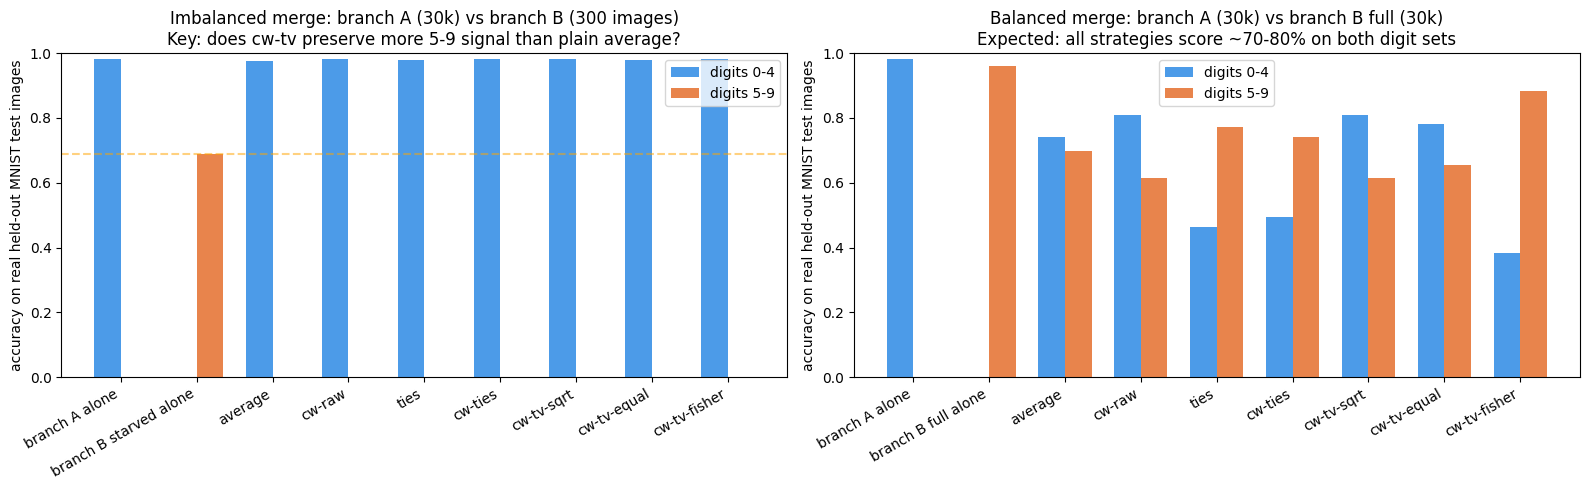

In [12]:
# ─── Step 9: Chart (imbalanced focus) ────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

imbalanced_labels = [
    r[0] for r in results
    if "(imbalanced)" in r[0] or r[0] in ("branch A alone", "branch B starved alone")
]
imbalanced_results = [r for r in results if r[0] in imbalanced_labels]

x = np.arange(len(imbalanced_results))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chart 1: Imbalanced experiment (the key one)
ax = axes[0]
ax.bar(x - width/2, [r[1] for r in imbalanced_results], width, label="digits 0-4", color="#4C9BE8")
ax.bar(x + width/2, [r[2] for r in imbalanced_results], width, label="digits 5-9", color="#E8844C")
ax.set_ylabel("accuracy on real held-out MNIST test images")
ax.set_title("Imbalanced merge: branch A (30k) vs branch B (300 images)\nKey: does cw-tv preserve more 5-9 signal than plain average?")
ax.set_xticks(x)
ax.set_xticklabels([r[0].replace(" (imbalanced)","") for r in imbalanced_results], rotation=30, ha="right")
ax.set_ylim(0, 1.0)
ax.legend()
ax.axhline(y=accuracy(branch_b_starved, test_b), color='orange', linestyle='--', alpha=0.5, label='B_starved ceiling')

# Chart 2: Balanced experiment (sanity check)
balanced_labels = [
    r[0] for r in results
    if "(balanced)" in r[0] or r[0] in ("branch A alone", "branch B full alone")
]
balanced_results = [r for r in results if r[0] in balanced_labels]
xb = np.arange(len(balanced_results))

ax2 = axes[1]
ax2.bar(xb - width/2, [r[1] for r in balanced_results], width, label="digits 0-4", color="#4C9BE8")
ax2.bar(xb + width/2, [r[2] for r in balanced_results], width, label="digits 5-9", color="#E8844C")
ax2.set_ylabel("accuracy on real held-out MNIST test images")
ax2.set_title("Balanced merge: branch A (30k) vs branch B full (30k)\nExpected: all strategies score ~70-80% on both digit sets")
ax2.set_xticks(xb)
ax2.set_xticklabels([r[0].replace(" (balanced)","") for r in balanced_results], rotation=30, ha="right")
ax2.set_ylim(0, 1.0)
ax2.legend()

plt.tight_layout()
plt.savefig("/content/cw_v3_comparison.png", dpi=120)
plt.show()


In [13]:
# ─── Step 10: Print the key comparison ────────────────────────────────────────
print("\n" + "="*70)
print("KEY COMPARISON — Imbalanced case (30k vs 300)")
print("="*70)
print(f"{'Strategy':<38}  {'digits 0-4':>12}  {'digits 5-9':>12}  {'full':>8}")
print("-" * 70)
for label, acc_a, acc_b, acc_full in results:
    if "(imbalanced)" in label or label in ("branch A alone", "branch B starved alone"):
        print(f"{label:<38}  {acc_a:>12.2%}  {acc_b:>12.2%}  {acc_full:>8.2%}")

print("\nWhat to look for:")
print("  cw-tv (task-vector) should score HIGHER on digits 5-9 than 'average'")
print("  because it correctly handles Δ_B being tiny (initialization noise)")
print("  rather than treating raw weights as if they contain meaningful signal.")
print("\n  The 'average' and 'cw-raw' collapse is expected: B_starved ≈ root,")
print("  so 0.5·A + 0.5·(≈root) = something dominated by A's 0-4 bias.")
print("\n  cw-tv formula: root + (0.99·Δ_A + 0.01·Δ_B_starved)")
print("  The 0.01·Δ_B preserves the weak 5-9 signal; A's 0-4 dominates as expected.")



KEY COMPARISON — Imbalanced case (30k vs 300)
Strategy                                  digits 0-4    digits 5-9      full
----------------------------------------------------------------------
branch A alone                                98.27%         0.00%    50.50%
branch B starved alone                         0.00%        69.02%    33.55%
average (imbalanced)                          97.66%         0.00%    50.19%
cw-raw (imbalanced)                           98.31%         0.00%    50.52%
ties (imbalanced)                             97.98%         0.00%    50.35%
cw-ties (imbalanced)                          98.17%         0.00%    50.45%
cw-tv-sqrt (imbalanced)                       98.31%         0.00%    50.52%
cw-tv-equal (imbalanced)                      97.94%         0.00%    50.33%
cw-tv-fisher (imbalanced)                     98.27%         0.00%    50.50%

What to look for:
  cw-tv (task-vector) should score HIGHER on digits 5-9 than 'average'
  because it correctly